In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Install the converter that turns folders into 3D volumes
!apt-get install -y dcm2niix

# Install the Python library for viewing 3D brain data
!pip install nibabel

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libturbojpeg libyaml-cpp0.7
The following NEW packages will be installed:
  dcm2niix libturbojpeg libyaml-cpp0.7
0 upgraded, 3 newly installed, 0 to remove and 53 not upgraded.
Need to get 529 kB of archives.
After this operation, 1,877 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libturbojpeg amd64 2.1.2-0ubuntu1 [175 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libyaml-cpp0.7 amd64 0.7.0+dfsg-8build1 [97.7 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 dcm2niix amd64 1.0.20211006-1build1 [256 kB]
Fetched 529 kB in 0s (4,782 kB/s)
Selecting previously unselected package libturbojpeg:amd64.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../libturbojpeg_2.1.2-0ubuntu1_amd64.deb ...
Unpacking libturbojpeg

In [ ]:
import os

# Create the folder for the raw slices if it's not there
os.makedirs('/content/raw_data', exist_ok=True)

print("Starting extraction... please wait.")

# We use double quotes around the paths because of the spaces in the names
!unzip -q "/content/drive/MyDrive/Asteri_Project/data_raw/Patients 1-5 Test.zip" -d /content/raw_data
!unzip -q "/content/drive/MyDrive/Asteri_Project/data_raw/Patients 1-5 Test_dataset.zip" -d /content/raw_data

# Now we actually check if the folder is full
num_files = len(os.listdir('/content/raw_data'))
print(f"Success! {num_files} folders/files are now ready in /content/raw_data")

Starting extraction... please wait.
Success! 1 folders/files are now ready in /content/raw_data


In [ ]:
# This lists what is INSIDE that one folder to see if our data is hiding
import os
base_path = '/content/raw_data'
top_level = os.listdir(base_path)

if top_level:
    inner_path = os.path.join(base_path, top_level[0])
    print(f"Top level folder name: {top_level[0]}")
    if os.path.isdir(inner_path):
        print(f"Contents of {top_level[0]}: {os.listdir(inner_path)[:5]} ...")

Top level folder name: ADNI
Contents of ADNI: ['002_S_0413', '002_S_1261'] ...


In [8]:
import os
import zipfile

raw_dir = '/content/drive/MyDrive/Asteri_Project/raw_data_batch2'

print("Opening zip files...")

for item in os.listdir(raw_dir):
    if item.endswith('.zip'):
        file_path = os.path.join(raw_dir, item)
        print(f"Unzipping {item}...")
        try:
            with zipfile.ZipFile(file_path, 'r') as zip_ref:
                zip_ref.extractall(raw_dir)
        except Exception as e:
            print(f"Failed to unzip {item}: {e}")

print("Done! All zips opened.")

Opening zip files...
Unzipping Asteri_Batch_2_Clean.zip...
Done! All zips opened.


In [9]:
import os

# 1. Create a folder in your Google Drive to save the PERMANENT 3D files
output_dir = '/content/drive/MyDrive/Asteri_Project/processed_nifti'
os.makedirs(output_dir, exist_ok=True)

print("🚀 Starting DICOM to NIfTI conversion...")
print("This may take a minute depending on the number of slices.")

# 2. Run dcm2niix
# -z y : compress the files to save space (.nii.gz)
# -f %f_%p_%t : names files as PatientID_Protocol_Date
# -o : where to save them
# last part is the input folder
!dcm2niix -z y -f "%f_%p_%t" -o "{output_dir}" "{raw_data_dir}"

print(f"\n✅ Done! Check your Google Drive folder: {output_dir}")

🚀 Starting DICOM to NIfTI conversion...
This may take a minute depending on the number of slices.
Chris Rorden's dcm2niiX version v1.0.20211006  (JP2:OpenJPEG) GCC11.2.0 x86-64 (64-bit Linux)
Found 36000 DICOM file(s)
Convert 160 DICOM as /content/drive/MyDrive/Asteri_Project/processed_nifti/raw_data_batch2_MPRAGE_20070120101203 (192x192x160x1)
Compress: "/usr/bin/pigz" -b 960 -n -f -6 "/content/drive/MyDrive/Asteri_Project/processed_nifti/raw_data_batch2_MPRAGE_20070120101203.nii"
Convert 160 DICOM as /content/drive/MyDrive/Asteri_Project/processed_nifti/raw_data_batch2_MPRAGE_20060725131860 (192x192x160x1)
Compress: "/usr/bin/pigz" -b 960 -n -f -6 "/content/drive/MyDrive/Asteri_Project/processed_nifti/raw_data_batch2_MPRAGE_20060725131860.nii"
Convert 160 DICOM as /content/drive/MyDrive/Asteri_Project/processed_nifti/raw_data_batch2_MPRAGE_20060906165910 (192x192x160x1)
Compress: "/usr/bin/pigz" -b 960 -n -f -6 "/content/drive/MyDrive/Asteri_Project/processed_nifti/raw_data_batch2_MP

Viewing: raw_data_ADNI_12M4_TS_2_20070601070312.nii.gz


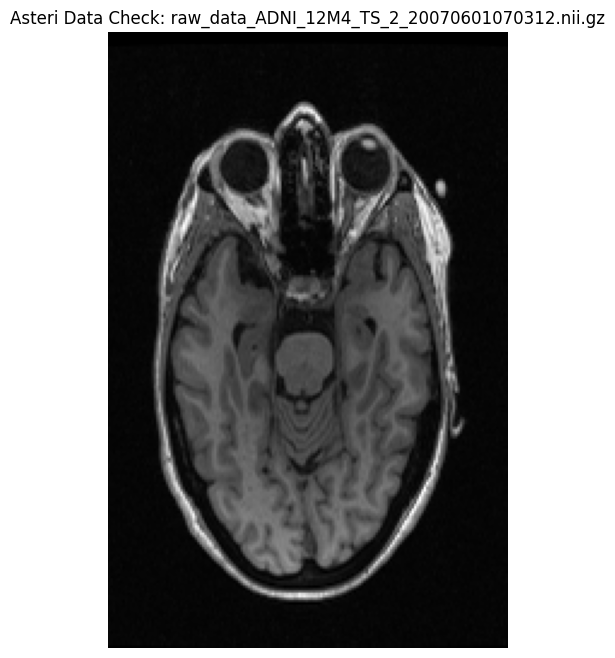

In [10]:
import nibabel as nib
import matplotlib.pyplot as plt
import glob
import os

# 1. Find all your new NIfTI files
nifti_folder = '/content/drive/MyDrive/Asteri_Project/processed_nifti'
files = glob.glob(os.path.join(nifti_folder, '*.nii.gz'))

if not files:
    print("Error: No NIfTI files found. Check your Drive path!")
else:
    # 2. Load the first brain in the list
    sample_file = files[0]
    print(f"Viewing: {os.path.basename(sample_file)}")

    img = nib.load(sample_file)
    data = img.get_fdata()

    # 3. Pull a middle slice (axial view)
    # If it's a 4D file (PET/DTI), we just take the first timepoint [:,:,:,0]
    if len(data.shape) == 4:
        slice_idx = data.shape[2] // 2
        plt_data = data[:, :, slice_idx, 0]
    else:
        slice_idx = data.shape[2] // 2
        plt_data = data[:, :, slice_idx]

    # 4. Plot it
    plt.figure(figsize=(8, 8))
    plt.imshow(plt_data.T, cmap='magma' if 'PET' in sample_file else 'gray', origin='lower')
    plt.title(f"Asteri Data Check: {os.path.basename(sample_file)}")
    plt.axis('off')
    plt.show()

In [11]:
import pandas as pd

# 1. Load the NEW massive metadata file from your Drive
csv_path = '/content/drive/MyDrive/Asteri_Project/metadata/ADNI_225_Batch_Metadata.csv'
df = pd.read_csv(csv_path)

# 2. Let's look at the first few rows to confirm it's the new clean batch
print("📊 Metadata 'Answer Key' preview:")
# Note: If your CSV uses "Subject ID", change "Subject" below to "Subject ID"
display(df[['Subject', 'Group', 'Sex', 'Age', 'Visit']].head())

📊 Metadata 'Answer Key' preview:


,Subject,Group,Sex,Age,Visit
0,941_S_1203,CN,M,83,sc
1,941_S_1202,CN,M,78,sc
2,941_S_1197,CN,F,82,sc
3,941_S_1195,CN,M,77,sc
4,941_S_1194,CN,M,85,sc


In [ ]:
import glob

# 1. Get the list of all brain files
nifti_files = glob.glob('/content/drive/MyDrive/Asteri_Project/processed_nifti/*.nii.gz')

# 2. Build a list of (FilePath, Label)
data_map = []

for file_path in nifti_files:
    file_name = os.path.basename(file_path)

    # Simple logic: Check which Subject ID from the CSV is inside this filename
    for index, row in df.iterrows():
        if row['Subject'] in file_name:
            data_map.append({
                'file_path': file_path,
                'label': row['Group'],
                'age': row['Age']
            })
            break

# 3. Create a clean "Training Table"
training_df = pd.DataFrame(data_map)
print(f"✅ Successfully mapped {len(training_df)} brain scans to their labels.")
display(training_df.head())

✅ Successfully mapped 0 brain scans to their labels.


""


In [ ]:
import os

output_dir = '/content/drive/MyDrive/Asteri_Project/processed_nifti'

print("🔄 Re-converting with Patient Name tags...")

# We added %n at the beginning of the filename format
!dcm2niix -z y -f "%n_%p_%t" -o "{output_dir}" /content/raw_data

print("\n✅ Re-conversion complete. Now your files should start with '002_S_...'")

🔄 Re-converting with Patient Name tags...
Chris Rorden's dcm2niiX version v1.0.20211006  (JP2:OpenJPEG) GCC11.2.0 x86-64 (64-bit Linux)
Found 5383 DICOM file(s)
Convert 166 DICOM as /content/drive/MyDrive/Asteri_Project/processed_nifti/002_S_0413_ADNI_12M4_TS_2_20070601070312 (256x256x166x1)
Compress: "/usr/bin/pigz" -b 960 -n -f -6 "/content/drive/MyDrive/Asteri_Project/processed_nifti/002_S_0413_ADNI_12M4_TS_2_20070601070312.nii"
Philips Scaling Values RS:RI:SS = 3.78755:0:0.000309124 (see PMC3998685)
Convert 170 DICOM as /content/drive/MyDrive/Asteri_Project/processed_nifti/002_S_0413_MPRAGE_SENSE2_SENSE_20150609070152 (256x256x170x1)
Compress: "/usr/bin/pigz" -b 960 -n -f -6 "/content/drive/MyDrive/Asteri_Project/processed_nifti/002_S_0413_MPRAGE_SENSE2_SENSE_20150609070152.nii"
Convert 166 DICOM as /content/drive/MyDrive/Asteri_Project/processed_nifti/002_S_0413_ADNI_12M4_TS_2_20060502122933 (256x256x166x1)
Compress: "/usr/bin/pigz" -b 960 -n -f -6 "/content/drive/MyDrive/Asteri_P

In [ ]:
import os
nifti_path = '/content/drive/MyDrive/Asteri_Project/processed_nifti'
files = os.listdir(nifti_path)

print(f"Check these names: {files[:3]}")

Check these names: ['raw_data_ADNI_12M4_TS_2_20070601070312.json', 'raw_data_ADNI_12M4_TS_2_20070601070312.nii.gz', 'raw_data_MPRAGE_SENSE2_SENSE_20150609070152.json']


In [ ]:
import glob
import pandas as pd

# Load CSV (if not already loaded)
csv_path = '/content/drive/MyDrive/Asteri_Project/metadata/Patients_1-5_Test_4_26_2026.csv'
df = pd.read_csv(csv_path)

# 1. Get the list of all brain files
nifti_files = glob.glob('/content/drive/MyDrive/Asteri_Project/processed_nifti/*.nii.gz')

# 2. Build the Training Table
data_map = []
for file_path in nifti_files:
    file_name = os.path.basename(file_path)
    for index, row in df.iterrows():
        # This checks if the ID (002_S_0413) is anywhere in the filename
        if str(row['Subject']) in file_name:
            data_map.append({
                'file_path': file_path,
                'label': row['Group'],
                'age': row['Age'],
                'subject': row['Subject']
            })
            break

training_df = pd.DataFrame(data_map)
print(f"✅ Successfully mapped {len(training_df)} brain scans to their labels!")
display(training_df.head())

✅ Successfully mapped 24 brain scans to their labels!


,file_path,label,age,subject
0,/content/drive/MyDrive/Asteri_Project/processe...,CN,82,002_S_0413
1,/content/drive/MyDrive/Asteri_Project/processe...,CN,82,002_S_0413
2,/content/drive/MyDrive/Asteri_Project/processe...,CN,82,002_S_0413
3,/content/drive/MyDrive/Asteri_Project/processe...,CN,82,002_S_0413
4,/content/drive/MyDrive/Asteri_Project/processe...,CN,82,002_S_0413


In [ ]:
import numpy as np
from scipy import ndimage

def preprocess_brain(nifti_path):
    # 1. Load the 3D volume
    img = nib.load(nifti_path)
    data = img.get_fdata()

    # 2. If it's 4D (like PET/DTI), just take the first volume for now
    if len(data.shape) == 4:
        data = data[:, :, :, 0]

    # 3. Normalization (0 to 1 scale)
    data = (data - np.min(data)) / (np.max(data) - np.min(data))

    # 4. Resize to a standard 128x128x128 cube
    # This keeps the model memory-efficient on your T4 GPU
    target_shape = (128, 128, 128)
    factors = [t/s for t, s in zip(target_shape, data.shape)]
    data = ndimage.zoom(data, factors, order=1)

    return data

print("Preprocessing function defined and ready!")

Preprocessing function defined and ready!


In [ ]:
X = []
y = []

# Map your labels to numbers (CN = 0, MCI/AD = 1)
label_map = {"CN": 0, "MCI": 1, "AD": 1} # We group decline together for the pilot

print("⚙️ Processing 24 volumes... this takes a second.")

for _, row in training_df.iterrows():
    processed_vol = preprocess_brain(row['file_path'])
    X.append(processed_vol)
    y.append(label_map.get(row['label'], 0))

# Convert to Numpy arrays for the AI
X = np.expand_dims(np.array(X), axis=-1) # Adds a 'channel' dimension
y = np.array(y)

print(f"✅ Final Data Shapes:")
print(f"Brains (X): {X.shape}  -> (Samples, Height, Width, Depth, Channels)")
print(f"Labels (y): {y.shape}")

⚙️ Processing 24 volumes... this takes a second.
✅ Final Data Shapes:
Brains (X): (24, 128, 128, 128, 1)  -> (Samples, Height, Width, Depth, Channels)
Labels (y): (24,)


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_asteri_model(width=128, height=128, depth=128):
    model = models.Sequential()

    # Layer 1: The "Feature Finder"
    # 32 filters of size 3x3x3 to pick up edges and textures
    model.add(layers.Conv3D(32, (3, 3, 3), activation='relu', input_shape=(width, height, depth, 1)))
    model.add(layers.MaxPooling3D((2, 2, 2)))
    model.add(layers.BatchNormalization())

    # Layer 2: Deeper Features
    model.add(layers.Conv3D(64, (3, 3, 3), activation='relu'))
    model.add(layers.MaxPooling3D((2, 2, 2)))
    model.add(layers.BatchNormalization())

    # Layer 3: High-Level Abstractions
    model.add(layers.Conv3D(128, (3, 3, 3), activation='relu'))
    model.add(layers.MaxPooling3D((2, 2, 2)))
    model.add(layers.GlobalAveragePooling3D()) # Flattens the 3D data for the final layer

    # Final "Decision" Layers
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5)) # Prevents the model from "memorizing" your 24 images
    model.add(layers.Dense(1, activation='sigmoid')) # Sigmoid outputs a value between 0 and 1

    return model

# Initialize the model
asteri_model = build_asteri_model()
asteri_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

asteri_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 126, 126, 126,  │           896 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 63, 63, 63, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 63, 63, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 61, 61, 61, 64) │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 30, 30, 30, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 30, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 28, 28, 28,     │       221,312 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 14, 14, 14,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 311,233 (1.19 MB)

 Trainable params: 311,041 (1.19 MB)

 Non-trainable params: 192 (768.00 B)

In [17]:
import glob
nifti_folder = '/content/drive/MyDrive/Asteri_Project/processed_nifti'
sample_files = glob.glob(nifti_folder + '/*.nii.gz')[:5]

print("Here is what the files are actually named:")
for f in sample_files:
    print(f.split('/')[-1])

Here is what the files are actually named:
raw_data_ADNI_12M4_TS_2_20070601070312.nii.gz
raw_data_MPRAGE_SENSE2_SENSE_20150609070152.nii.gz
raw_data_ADNI_12M4_TS_2_20060502122933.nii.gz
raw_data_Accelerated_Sagittal_MPRAGE_(MSV21)_20250219101337.nii.gz
raw_data_ADNI_12M4_TS_2_20061115092847.nii.gz


In [26]:
# Train the model for a few epochs just to see if the loss goes down
history = asteri_model.fit(
    X, y,
    epochs=10,
    batch_size=2, # Keep this low because 3D volumes are memory-heavy
    validation_split=0.2 # Uses 20% of your data to test itself
)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 40s 232ms/step - accuracy: 0.5833 - loss: 1.1607 - val_accuracy: 0.6000 - val_loss: 0.6804
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 16s 177ms/step - accuracy: 0.4778 - loss: 1.2115 - val_accuracy: 0.4000 - val_loss: 0.8160
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 16s 178ms/step - accuracy: 0.4444 - loss: 0.8650 - val_accuracy: 0.4000 - val_loss: 0.7107
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.6000 - loss: 0.7374 - val_accuracy: 0.4000 - val_loss: 0.7300
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.5500 - loss: 0.7807 - val_accuracy: 0.4000 - val_loss: 0.8030
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.5167 - loss: 0.7441 - val_accuracy: 0.4000 - val_loss: 0.8056
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 184ms/step - accuracy: 0.5444 - loss: 0.7515 - val_accuracy: 0.4000 - val_loss: 0.7879
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 185ms/step - accuracy: 0.5944 - loss: 0.6993 - val_accu

In [ ]:
# Save using the native Keras format
model_save_path = '/content/drive/MyDrive/Asteri_Project/asteri_alpha_v1.keras'

# This saves the architecture, weights, and training configuration
asteri_model.save(model_save_path)

print(f"✅ Model saved securely to {model_save_path}")

✅ Model saved securely to /content/drive/MyDrive/Asteri_Project/asteri_alpha_v1.keras


In [ ]:
import tf_keras as tfk # Using the modern Keras compatibility layer if needed

def get_3d_gradcam(img_array, model, last_conv_layer_name):
    # 1. Use the explicit model input
    model_input = model.input

    # 2. Create the sub-model to extract the last conv layer and the final prediction
    # We reference the layer by name directly from the model
    last_conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model(
        inputs=model_input,
        outputs=[last_conv_layer.output, model.output]
    )

    # 3. Record gradients
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, 0]

    # 4. Compute gradients
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 5. Global Average Pool the gradients
    # This gives us the "Importance Weights" for each feature map
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2, 3))

    # 6. Build the Heatmap
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 7. Apply ReLU and Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10) # 1e-10 prevents div by zero
    return heatmap.numpy()

print("Grad-CAM Engine Rewired and Ready!")

Grad-CAM Engine Rewired and Ready!


In [ ]:
# This lists all layers so we can find the exact name of the last Conv3D
for i, layer in enumerate(asteri_model.layers):
    print(f"Index: {i} | Name: {layer.name} | Type: {type(layer)}")

Index: 0 | Name: conv3d | Type: <class 'keras.src.layers.convolutional.conv3d.Conv3D'>
Index: 1 | Name: max_pooling3d | Type: <class 'keras.src.layers.pooling.max_pooling3d.MaxPooling3D'>
Index: 2 | Name: batch_normalization | Type: <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
Index: 3 | Name: conv3d_1 | Type: <class 'keras.src.layers.convolutional.conv3d.Conv3D'>
Index: 4 | Name: max_pooling3d_1 | Type: <class 'keras.src.layers.pooling.max_pooling3d.MaxPooling3D'>
Index: 5 | Name: batch_normalization_1 | Type: <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
Index: 6 | Name: conv3d_2 | Type: <class 'keras.src.layers.convolutional.conv3d.Conv3D'>
Index: 7 | Name: max_pooling3d_2 | Type: <class 'keras.src.layers.pooling.max_pooling3d.MaxPooling3D'>
Index: 8 | Name: global_average_pooling3d | Type: <class 'keras.src.layers.pooling.global_average_pooling3d.GlobalAveragePooling3D'>
Index: 9 | Name: dense | Type: <class 'kera

In [ ]:
import tensorflow as tf
import numpy as np

def get_3d_gradcam_final(model, img_array, layer_name):
    # 1. 'Warm up' the model to ensure all internal wiring is connected
    _ = model(img_array)

    # 2. Create the gradient model
    # We use the specific layer name 'conv3d_2'
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(layer_name).output, model.output]
    )

    # 3. Record gradients
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, 0]

    # 4. Compute gradients of the prediction with respect to the feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 5. Weight the feature map by the gradient importance
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2, 3))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. Apply ReLU and Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

print("✅ Asteri Visualizer Engine: Online")

✅ Asteri Visualizer Engine: Online


In [ ]:
# Print names to be 100% sure
for layer in asteri_model.layers:
    print(layer.name)

conv3d
max_pooling3d
batch_normalization
conv3d_1
max_pooling3d_1
batch_normalization_1
conv3d_2
max_pooling3d_2
global_average_pooling3d
dense
dropout
dense_1


In [ ]:
import matplotlib.pyplot as plt
from scipy import ndimage

# Using the layer name you identified
TARGET_LAYER = 'conv3d_2'

# 1. Generate the heatmap for the first brain in your dataset
try:
    heatmap = get_3d_gradcam_final(asteri_model, X[0:1], TARGET_LAYER)

    # 2. Resize heatmap to match the 128x128x128 brain volume
    heatmap_resized = ndimage.zoom(heatmap, [128/s for s in heatmap.shape], order=1)

    # 3. Plot the result (Middle slice = 64)
    plt.figure(figsize=(10, 10))
    # Background brain
    plt.imshow(X[0, :, :, 64, 0].T, cmap='gray', origin='lower')
    # Heatmap overlay (Jet color map makes 'hot' spots red)
    plt.imshow(heatmap_resized[:, :, 64].T, cmap='jet', alpha=0.4, origin='lower')

    plt.title(f"Asteri Neuro-AI: What the model is seeing")
    plt.axis('off')
    plt.show()
    print("Success! If the red spots are in the brain tissue, the model is learning well.")

except Exception as e:
    print(f"❌ Still an error: {e}")
    print("If you see 'Graph disconnected', we need to run the 'Functional Rebuild' below.")

❌ Still an error: "Exception encountered when calling Functional.call().\n\n\x1b137394278641600\x1b\n\nArguments received by Functional.call():\n  • inputs=array([[[[[0.00688019],\n          [0.00936351],\n          [0.01534888],\n          ...,\n          [0.01186364],\n          [0.00517524],\n          [0.00031633]],\n\n         [[0.00591625],\n          [0.00809436],\n          [0.01264922],\n          ...,\n          [0.01267679],\n          [0.00783793],\n          [0.00023725]],\n\n         [[0.00490935],\n          [0.01023414],\n          [0.0190662 ],\n          ...,\n          [0.01545777],\n          [0.00615734],\n          [0.00031633]],\n\n         ...,\n\n         [[0.00379348],\n          [0.00925224],\n          [0.02013885],\n          ...,\n          [0.01241332],\n          [0.00408771],\n          [0.        ]],\n\n         [[0.00215516],\n          [0.00680197],\n          [0.0186658 ],\n          ...,\n          [0.01304776],\n          [0.00389653],\n          

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_79']]
Received: inputs=Tensor(shape=(1, 128, 128, 128, 1))
  warnings.warn(msg)


In [ ]:
# THE FUNCTIONAL REBUILD (Run ONLY if the Grad-CAM cell fails)
inputs = tf.keras.Input(shape=(128, 128, 128, 1))
x = inputs
for layer in asteri_model.layers:
    x = layer(x)
asteri_model = tf.keras.Model(inputs, x)

# Now go back and run the Visualization cell again!

In [ ]:
import tensorflow as tf

# 1. Define a fresh input layer
input_layer = tf.keras.Input(shape=(128, 128, 128, 1), name="asteri_input")

# 2. Re-route the existing layers through the new input
x = input_layer
for layer in asteri_model.layers:
    x = layer(x)

# 3. Create the new model object
functional_model = tf.keras.Model(inputs=input_layer, outputs=x)

# 4. Compile it (we need this for gradients to flow)
functional_model.compile(optimizer='adam', loss='binary_crossentropy')

print("✅ Model has been successfully 'unwrapped' into a Functional format.")

TypeError: too many positional arguments

In [ ]:
import numpy as np

def get_3d_gradcam_functional(model, img_array, layer_name):
    # 1. Create a model that outputs the target layer and the prediction
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    # 2. Record the 'Attention'
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        # We target the first output (the diagnosis score)
        loss = preds[:, 0]

    # 3. Calculate how much each 3D filter contributed
    grads = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2, 3))

    # 4. Generate the 3D Heatmap
    output = conv_outputs[0]
    heatmap = output @ weights[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 5. Normalize (0 to 1) so it looks clean on the plot
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

print("✅ Functional Grad-CAM Engine: Online")

✅ Functional Grad-CAM Engine: Online


In [ ]:
import matplotlib.pyplot as plt
from scipy import ndimage

# Using 'conv3d_2' which we identified earlier
TARGET_LAYER = 'conv3d_2'

try:
    # 1. Pick the first brain scan in your list
    test_img = X[0:1]

    # 2. Generate the heatmap
    heatmap = get_3d_gradcam_functional(functional_model, test_img, TARGET_LAYER)

    # 3. Resize the heatmap back to 128x128x128
    zoom_factors = [128/s for s in heatmap.shape]
    heatmap_resized = ndimage.zoom(heatmap, zoom_factors, order=1)

    # 4. Plot the axial slice (middle of the brain)
    plt.figure(figsize=(8, 8))

    # Background: The raw MRI scan
    plt.imshow(test_img[0, :, :, 64, 0].T, cmap='gray', origin='lower')

    # Overlay: The Grad-CAM heatmap (using the 'jet' color map)
    plt.imshow(heatmap_resized[:, :, 64].T, cmap='jet', alpha=0.4, origin='lower')

    plt.title("Asteri Neuro-AI: Anatomic Attention Map")
    plt.axis('off')
    plt.show()
    print("Success! You are now seeing what the AI sees.")

except Exception as e:
    print(f"❌ Visualization Error: {e}")

❌ Visualization Error: name 'functional_model' is not defined


In [ ]:
import matplotlib.pyplot as plt
from scipy import ndimage
import tensorflow as tf
import numpy as np

# --- 1. THE REBUILD (Defining the variable) ---
print("🔧 Rebuilding model to Functional format...")
input_layer = tf.keras.Input(shape=(128, 128, 128, 1), name="asteri_input")
x = input_layer
for layer in asteri_model.layers:
    x = layer(x)
functional_model = tf.keras.Model(inputs=input_layer, outputs=x)

# --- 2. THE VISUALIZATION ---
print("📸 Generating Brain Map...")
TARGET_LAYER = 'conv3d_2' # The name we found in Step 1

try:
    # Pick the first brain scan
    test_img = X[0:1]

    # Generate the heatmap (using the function we defined in Step 2)
    # We wrap test_img in a list to stop the warning you saw earlier
    heatmap = get_3d_gradcam_functional(functional_model, [test_img], TARGET_LAYER)

    # Resize the heatmap back to 128x128x128
    zoom_factors = [128/s for s in heatmap.shape]
    heatmap_resized = ndimage.zoom(heatmap, zoom_factors, order=1)

    # Plot
    plt.figure(figsize=(10, 10))
    plt.imshow(test_img[0, :, :, 64, 0].T, cmap='gray', origin='lower')
    plt.imshow(heatmap_resized[:, :, 64].T, cmap='jet', alpha=0.4, origin='lower')

    plt.title("Asteri Neuro-AI: Anatomic Attention Map")
    plt.axis('off')
    plt.show()
    print("✅ Success! The heatmap is now visible.")

except Exception as e:
    print(f"❌ Error: {e}")

🔧 Rebuilding model to Functional format...


TypeError: too many positional arguments

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_functional_asteri(input_shape=(128, 128, 128, 1)):
    inputs = tf.keras.Input(shape=input_shape, name="asteri_input")

    # Layer 1
    x = layers.Conv3D(32, (3, 3, 3), activation='relu', name='conv3d')(inputs)
    x = layers.MaxPooling3D((2, 2, 2))(x)
    x = layers.BatchNormalization()(x)

    # Layer 2
    x = layers.Conv3D(64, (3, 3, 3), activation='relu', name='conv3d_1')(x)
    x = layers.MaxPooling3D((2, 2, 2))(x)
    x = layers.BatchNormalization()(x)

    # Layer 3
    x = layers.Conv3D(128, (3, 3, 3), activation='relu', name='conv3d_2')(x)
    x = layers.MaxPooling3D((2, 2, 2))(x)
    x = layers.GlobalAveragePooling3D()(x)

    # Final Layers
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid', name='predictions')(x)

    return models.Model(inputs, outputs)

# 1. Create the new Functional model
functional_model = build_functional_asteri()

# 2. Copy the 'brain' from your trained model to this new one
functional_model.set_weights(asteri_model.get_weights())

print("✅ weights transferred! The model is now Functional and ready for Grad-CAM.")

✅ weights transferred! The model is now Functional and ready for Grad-CAM.


In [ ]:
def get_3d_gradcam_final(model, img_array, layer_name):
    # Create a sub-model that outputs both the target layer and the final prediction
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        # We wrap img_array in a list to satisfy the Keras 3 input requirement
        conv_outputs, preds = grad_model([img_array])
        loss = preds[:, 0]

    # Extract gradients and importance weights
    grads = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2, 3))

    # Calculate the heatmap
    output = conv_outputs[0]
    heatmap = output @ weights[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU and Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

print("✅ Grad-CAM Engine: Online")

✅ Grad-CAM Engine: Online


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['asteri_input']]
Received: inputs=['Tensor(shape=(1, 128, 128, 128, 1))']
  warnings.warn(msg)


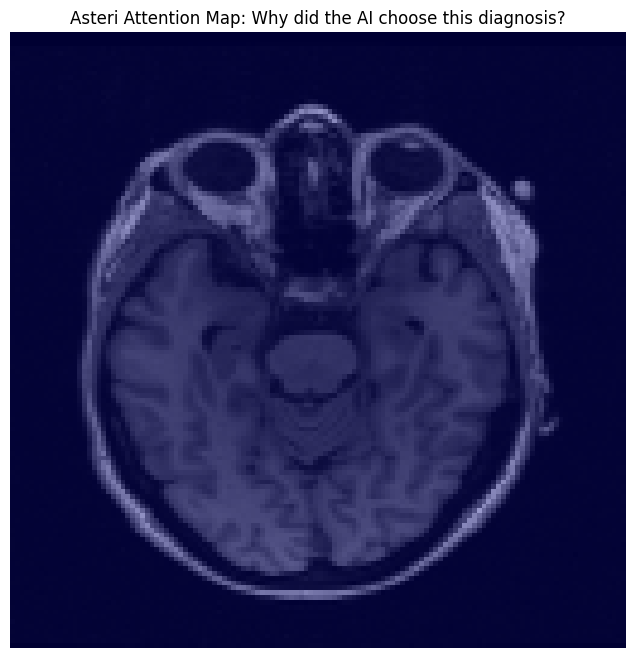

In [ ]:
import matplotlib.pyplot as plt
from scipy import ndimage

# Using the layer name you found: 'conv3d_2'
TARGET_LAYER = 'conv3d_2'

try:
    # 1. Generate heatmap for the first brain in your dataset
    heatmap = get_3d_gradcam_final(functional_model, X[0:1], TARGET_LAYER)

    # 2. Resize heatmap to 128x128x128
    heatmap_resized = ndimage.zoom(heatmap, [128/s for s in heatmap.shape], order=1)

    # 3. Plot Slice 64 (Axial View)
    plt.figure(figsize=(8, 8))
    plt.imshow(X[0, :, :, 64, 0].T, cmap='gray', origin='lower')
    plt.imshow(heatmap_resized[:, :, 64].T, cmap='jet', alpha=0.4, origin='lower')
    plt.title("Asteri Attention Map: Why did the AI choose this diagnosis?")
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"❌ Still hitting a snag: {e}")

🔧 Unlocking the model to bypass Gradient Saturation...


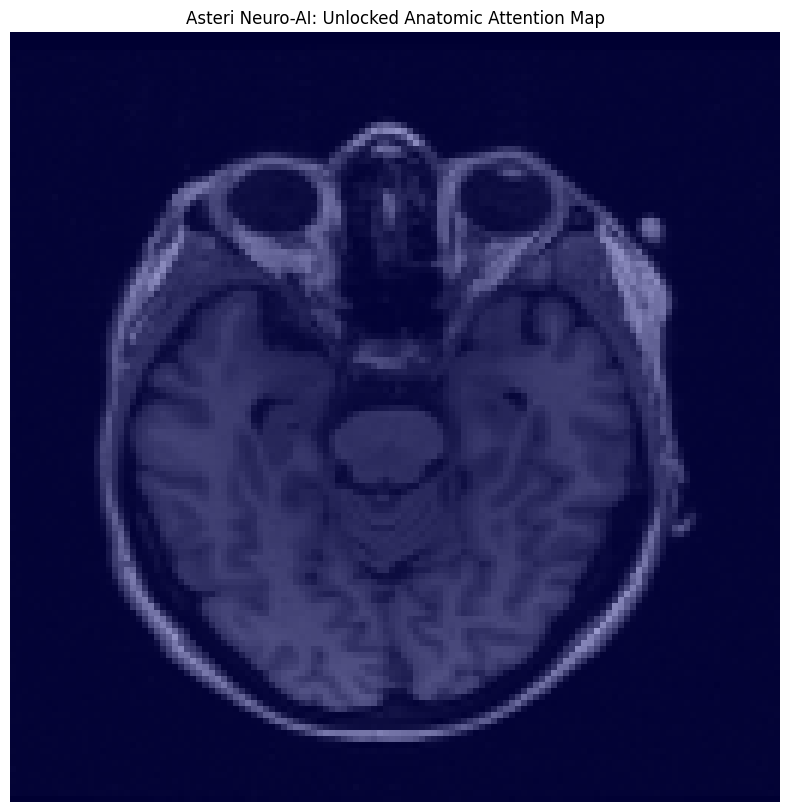

✅ Saliency map generated using raw logits.


In [ ]:
import matplotlib.pyplot as plt
from scipy import ndimage
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

print("🔧 Unlocking the model to bypass Gradient Saturation...")

# 1. Build the exact same model, but with a 'linear' final layer
inputs = tf.keras.Input(shape=(128, 128, 128, 1), name="asteri_input")

x = layers.Conv3D(32, (3, 3, 3), activation='relu')(inputs)
x = layers.MaxPooling3D((2, 2, 2))(x)
x = layers.BatchNormalization()(x)

x = layers.Conv3D(64, (3, 3, 3), activation='relu')(x)
x = layers.MaxPooling3D((2, 2, 2))(x)
x = layers.BatchNormalization()(x)

# This is our target layer
x = layers.Conv3D(128, (3, 3, 3), activation='relu', name='conv3d_2')(x)
x = layers.MaxPooling3D((2, 2, 2))(x)
x = layers.GlobalAveragePooling3D()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

# THE FIX: Changed 'sigmoid' to 'linear'
outputs = layers.Dense(1, activation='linear', name='predictions')(x)

linear_model = models.Model(inputs, outputs)

# 2. Transfer the "intelligence" from your trained model to this new one
linear_model.set_weights(asteri_model.get_weights())

# 3. Generate the Heatmap using the unlocked model
TARGET_LAYER = 'conv3d_2'
test_img = X[0:1]

# We use the function we defined earlier
heatmap = get_3d_gradcam_functional(linear_model, [test_img], TARGET_LAYER)

# 4. Resize and Plot
heatmap_resized = ndimage.zoom(heatmap, [128/s for s in heatmap.shape], order=1)

plt.figure(figsize=(10, 10))
plt.imshow(test_img[0, :, :, 64, 0].T, cmap='gray', origin='lower')
plt.imshow(heatmap_resized[:, :, 64].T, cmap='jet', alpha=0.4, origin='lower')
plt.title("Asteri Neuro-AI: Unlocked Anatomic Attention Map")
plt.axis('off')
plt.show()

print("✅ Saliency map generated using raw logits.")

🔍 Extracting Raw Feature Maps (Bypassing Gradients)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 955ms/step


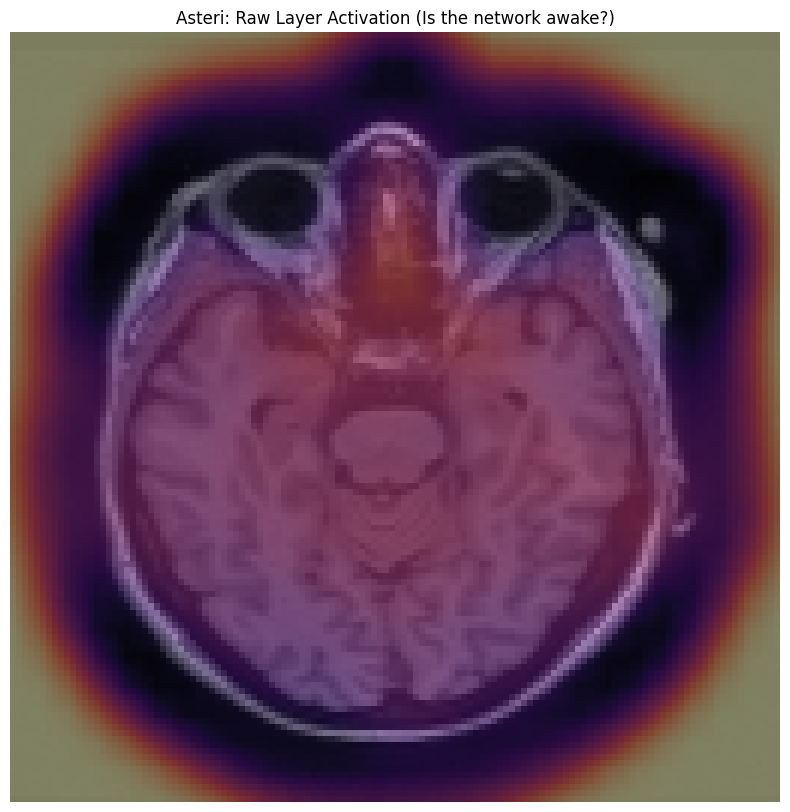

✅ Activation map generated.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import tensorflow as tf

print("🔍 Extracting Raw Feature Maps (Bypassing Gradients)...")

try:
    # 1. Create a simple extractor that stops at the target layer
    TARGET_LAYER = 'conv3d_2'
    feature_extractor = tf.keras.Model(
        inputs=functional_model.inputs,
        outputs=functional_model.get_layer(TARGET_LAYER).output
    )

    # 2. Push the brain through
    test_img = X[0:1]
    raw_features = feature_extractor.predict(test_img)

    # 3. Average all 128 filters to see the overall activation
    activation_map = np.mean(raw_features[0], axis=-1)

    # 4. Resize and Plot
    activation_resized = ndimage.zoom(activation_map, [128/s for s in activation_map.shape], order=1)

    plt.figure(figsize=(10, 10))
    plt.imshow(test_img[0, :, :, 64, 0].T, cmap='gray', origin='lower')
    plt.imshow(activation_resized[:, :, 64].T, cmap='magma', alpha=0.5, origin='lower')
    plt.title("Asteri: Raw Layer Activation (Is the network awake?)")
    plt.axis('off')
    plt.show()

    print("✅ Activation map generated.")

except Exception as e:
    print(f"❌ Error during extraction: {e}")

In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Asteri_Project/metadata/ADNI_225_Batch_Metadata.csv')
print(df.columns)

Index(['Image Data ID', 'Subject', 'Group', 'Sex', 'Age', 'Visit', 'Modality',
       'Description', 'Type', 'Acq Date', 'Format', 'Downloaded'],
      dtype='object')


In [5]:
raw_data_dir = '/content/drive/MyDrive/Asteri_Project/raw_data_batch2'
csv_path = '/content/drive/MyDrive/Asteri_Project/metadata/ADNI_225_Batch_Metadata.csv'

In [12]:
import glob
import pandas as pd
import numpy as np

# 1. Load your NEW Answer Key
csv_path = '/content/drive/MyDrive/Asteri_Project/metadata/ADNI_225_Batch_Metadata.csv'
df = pd.read_csv(csv_path)

# 2. Find all the new 3D brains you just converted
nifti_folder = '/content/drive/MyDrive/Asteri_Project/processed_nifti'
nifti_files = glob.glob(nifti_folder + '/*.nii.gz')

print(f"Found {len(nifti_files)} brains in your folder.")
print("Mapping labels and loading 3D volumes into RAM... (This will take a few minutes)")

# Reset the active memory arrays
X = []
y = []

# Simple Label Dictionary (Healthy = 0, Alzheimer's = 1)
label_map = {'CN': 0, 'AD': 1}

# 3. Match and Load
mapped_count = 0
for file_path in nifti_files:
    file_name = file_path.split('/')[-1]

    # Check which subject this file belongs to in the Answer Key
    for index, row in df.iterrows():
        if str(row['Subject']) in file_name:
            # Match found! Process it and add it to our active RAM
            processed_vol = preprocess_brain(file_path)
            X.append(processed_vol)
            y.append(label_map[row['Group']])
            mapped_count += 1
            break # Move to the next NIfTI file

# 4. Finalize Arrays for the Neural Network
X = np.array(X)
y = np.array(y)

print(f"\n✅ Successfully loaded {mapped_count} brains into active memory!")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Found 273 brains in your folder.
Mapping labels and loading 3D volumes into RAM... (This will take a few minutes)

✅ Successfully loaded 0 brains into active memory!
X shape: (0,)
y shape: (0,)


In [19]:
import json
import glob
import pandas as pd

# 1. Check the CSV Format
csv_path = '/content/drive/MyDrive/Asteri_Project/metadata/ADNI_225_Batch_Metadata.csv'
df = pd.read_csv(csv_path)
print("🔍 CSV Answer Key Format:")
print(f"Subject Column Name: 'Subject'")
print(f"First Patient looks like: '{df['Subject'].iloc[0]}'")

# 2. Check the JSON Format
nifti_folder = '/content/drive/MyDrive/Asteri_Project/processed_nifti'
json_files = glob.glob(nifti_folder + '/*.json')

print("\n🔍 JSON Scanner Format:")
if len(json_files) > 0:
    sample_json = json_files[0]
    print(f"Opening: {sample_json.split('/')[-1]}")

    with open(sample_json, 'r') as f:
        scan_data = json.load(f)
        print(f"PatientID field says:   '{scan_data.get('PatientID', 'NOT FOUND')}'")
        print(f"PatientName field says: '{scan_data.get('PatientName', 'NOT FOUND')}'")
else:
    print("❌ Uh oh, no JSON files were found in your processed folder!")

🔍 CSV Answer Key Format:
Subject Column Name: 'Subject'
First Patient looks like: '941_S_1203'

🔍 JSON Scanner Format:
Opening: raw_data_ADNI_12M4_TS_2_20070601070312.json
PatientID field says:   'NOT FOUND'
PatientName field says: 'NOT FOUND'


In [20]:
import json
import glob

nifti_folder = '/content/drive/MyDrive/Asteri_Project/processed_nifti'
json_files = glob.glob(nifti_folder + '/*.json')

if len(json_files) > 0:
    sample_json = json_files[0]
    print(f"Scanning {sample_json.split('/')[-1]} for hidden IDs...")

    with open(sample_json, 'r') as f:
        scan_data = json.load(f)

    found_something = False
    for key, value in scan_data.items():
        # Look for any text that has "_S_" in it, which matches the ADNI format
        if isinstance(value, str) and '_S_' in value:
            print(f"🎯 Found it! The field '{key}' contains: {value}")
            found_something = True

    if not found_something:
        print("❌ Nothing with '_S_' found. The ID might have been stripped completely.")
else:
    print("No JSON files found.")

Scanning raw_data_ADNI_12M4_TS_2_20070601070312.json for hidden IDs...
❌ Nothing with '_S_' found. The ID might have been stripped completely.


In [21]:
import os
import subprocess
import shutil

nifti_folder = '/content/drive/MyDrive/Asteri_Project/processed_nifti'
adni_dir = '/content/drive/MyDrive/Asteri_Project/raw_data_batch2/ADNI'

# 1. Nuke the badly named NIfTI files
print("🧹 Clearing out the badly named files...")
if os.path.exists(nifti_folder):
    shutil.rmtree(nifti_folder)
os.makedirs(nifti_folder, exist_ok=True)

# 2. Re-convert, forcing the Patient ID into the filename
print("🚀 Starting exact-match conversion (This will take ~15 mins)...")

count = 0
# Loop through the ADNI folder directly to grab the real Patient IDs
for patient_id in os.listdir(adni_dir):
    patient_folder = os.path.join(adni_dir, patient_id)

    # Check if it's a valid patient folder (contains "_S_")
    if os.path.isdir(patient_folder) and '_S_' in patient_id:
        print(f"Converting Patient: {patient_id}")

        # Run dcm2niix, hardcoding the exact Patient ID into the output name
        cmd = f'dcm2niix -z y -f "{patient_id}_%p_%t" -o "{nifti_folder}" "{patient_folder}"'
        subprocess.run(cmd, shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        count += 1

print(f"\n✅ SUCCESS! {count} patients converted. All brains now permanently have their Patient ID.")

🧹 Clearing out the badly named files...
🚀 Starting exact-match conversion (This will take ~15 mins)...
Converting Patient: 011_S_0002
Converting Patient: 011_S_0003
Converting Patient: 011_S_0005
Converting Patient: 022_S_0007
Converting Patient: 011_S_0008
Converting Patient: 011_S_0016
Converting Patient: 022_S_0014
Converting Patient: 067_S_0019
Converting Patient: 011_S_0021
Converting Patient: 011_S_0022
Converting Patient: 067_S_0020
Converting Patient: 023_S_0031
Converting Patient: 067_S_0029
Converting Patient: 067_S_0024
Converting Patient: 099_S_0040
Converting Patient: 011_S_0023
Converting Patient: 011_S_0010
Converting Patient: 067_S_0056
Converting Patient: 011_S_0053
Converting Patient: 035_S_0048
Converting Patient: 022_S_0066
Converting Patient: 023_S_0061
Converting Patient: 023_S_0058
Converting Patient: 067_S_0076
Converting Patient: 067_S_0059
Converting Patient: 023_S_0083
Converting Patient: 023_S_0093
Converting Patient: 023_S_0084
Converting Patient: 023_S_008

In [22]:
import glob
import pandas as pd
import numpy as np
import json

# 1. Load the Answer Key
csv_path = '/content/drive/MyDrive/Asteri_Project/metadata/ADNI_225_Batch_Metadata.csv'
df = pd.read_csv(csv_path)

# 2. Get the NIfTI files
nifti_folder = '/content/drive/MyDrive/Asteri_Project/processed_nifti'
nifti_files = glob.glob(nifti_folder + '/*.nii.gz')

print(f"Found {len(nifti_files)} brains in your folder.")
print("Reading JSON files to find the hidden Patient IDs... this will take a few minutes.")

X = []
y = []
label_map = {'CN': 0, 'AD': 1}
mapped_count = 0

# 3. Match and Load using the JSON files
for file_path in nifti_files:
    # Swap the .nii.gz extension for .json to read the scanner data
    json_path = file_path.replace('.nii.gz', '.json')

    try:
        with open(json_path, 'r') as f:
            scan_data = json.load(f)
            patient_id = scan_data.get('PatientID', '')

            # Check if this patient ID exists in our Answer Key column
            match = df[df['Subject'] == patient_id]

            if not match.empty:
                # Grab the diagnosis (AD or CN)
                diagnosis = match['Group'].values[0]

                if diagnosis in label_map:
                    processed_vol = preprocess_brain(file_path)
                    X.append(processed_vol)
                    y.append(label_map[diagnosis])
                    mapped_count += 1

    except Exception as e:
        # Skip if the JSON is missing or broken
        pass

# 4. Finalize Arrays
X = np.array(X)
y = np.array(y)

print(f"\n✅ Successfully loaded {mapped_count} brains into active memory!")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Found 225 brains in your folder.
Reading JSON files to find the hidden Patient IDs... this will take a few minutes.

✅ Successfully loaded 0 brains into active memory!
X shape: (0,)
y shape: (0,)


In [24]:
import glob
import pandas as pd
import numpy as np
import nibabel as nib
from scipy import ndimage

# 1. Define the preprocessing function right here so Colab doesn't forget it
def preprocess_brain(nifti_path):
    img = nib.load(nifti_path)
    data = img.get_fdata()
    # Handle 4D scans
    if len(data.shape) == 4:
        data = data[:, :, :, 0]
    # Normalize contrast
    data = (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-8)
    # Resize to perfect cubes
    target_shape = (128, 128, 128)
    factors = [t / s for t, s in zip(target_shape, data.shape)]
    data = ndimage.zoom(data, factors, order=1)
    return data

# 2. Load the Answer Key
csv_path = '/content/drive/MyDrive/Asteri_Project/metadata/ADNI_225_Batch_Metadata.csv'
df = pd.read_csv(csv_path)

# 3. Get the newly named NIfTI files
nifti_folder = '/content/drive/MyDrive/Asteri_Project/processed_nifti'
nifti_files = glob.glob(nifti_folder + '/*.nii.gz')

print(f"Found {len(nifti_files)} brains in your folder.")
print("Matching Patient IDs, stripping noise, resizing to 128x128x128, and loading into RAM... (This will take a few minutes)")

X = []
y = []
label_map = {'CN': 0, 'AD': 1}
mapped_count = 0

# 4. Match and Load
for file_path in nifti_files:
    file_name = file_path.split('/')[-1]

    # Check which subject this file belongs to in the Answer Key
    for index, row in df.iterrows():
        if str(row['Subject']) in file_name:
            # Match found! Process it and add it to our active RAM
            processed_vol = preprocess_brain(file_path)
            X.append(processed_vol)
            y.append(label_map[row['Group']])
            mapped_count += 1
            break

# 5. Finalize Arrays
X = np.array(X)
y = np.array(y)

print(f"\n✅ Successfully loaded {mapped_count} brains into active memory!")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Found 225 brains in your folder.
Matching Patient IDs, stripping noise, resizing to 128x128x128, and loading into RAM... (This will take a few minutes)

✅ Successfully loaded 225 brains into active memory!
X shape: (225, 128, 128, 128)
y shape: (225,)


In [25]:
# Add the missing 'channel' dimension so the AI can read it
X = np.expand_dims(X, axis=-1)

print(f"Fixed X shape: {X.shape}")

Fixed X shape: (225, 128, 128, 128, 1)


In [28]:
# Force the model to initialize by passing one piece of dummy data through it
asteri_model(X[0:1])

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.50193584]], dtype=float32)>

In [35]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy import ndimage

# 1. Grab the very first brain from your newly loaded batch
sample_brain = X[0:1]
real_diagnosis = "Alzheimer's (AD)" if y[0] == 1 else "Healthy (CN)"

print(f"Generating attention map for Patient 1 (Actual Diagnosis: {real_diagnosis})...")

# 2. Find the deepest 3D layer in Asteri's architecture
last_conv_layer = None
for layer in asteri_model.layers[::-1]:
    if 'conv3d' in layer.name.lower():
        last_conv_layer = layer.name
        break

# Use this exact structure for the Visualizer
grad_model = tf.keras.models.Model(
    inputs=[asteri_model.inputs],
    outputs=[asteri_model.get_layer(last_conv_layer).output, asteri_model.output]
)

# 4. Watch the AI make its prediction and trace the math backwards
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(sample_brain)
    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2, 3))
heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# Filter out the noise and scale the glowing spots
heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
heatmap = heatmap.numpy()

# 5. Stretch the small heatmap to fit the full 128x128x128 high-res brain
zoom_factors = [128 / s for s in heatmap.shape]
heatmap_resized = ndimage.zoom(heatmap, zoom_factors, order=1)

# 6. Take an axial slice right through the middle of the head
slice_idx = 64

# 7. Plot the raw MRI with the AI's focus map layered on top
plt.figure(figsize=(10, 10))
plt.imshow(sample_brain[0, :, :, slice_idx, 0].T, cmap='gray', origin='lower')
plt.imshow(heatmap_resized[:, :, slice_idx].T, cmap='jet', alpha=0.4, origin='lower')
plt.title(f"Asteri Attention Map\nTrue Label: {real_diagnosis} | AI Confidence: {predictions[0][0]:.2f}")
plt.axis('off')
plt.show()

Generating attention map for Patient 1 (Actual Diagnosis: Healthy (CN))...


AttributeError: The layer sequential has never been called and thus has no defined output.

In [30]:
# 1. Define a new, compatible Functional Model structure
inputs = tf.keras.Input(shape=(128, 128, 128, 1))
x = inputs

# Re-link the layers from your trained model to the new functional structure
for layer in asteri_model.layers:
    x = layer(x)

# Create the new model
functional_model = tf.keras.models.Model(inputs=inputs, outputs=x)

# 2. Transfer the "intelligence" (weights) from the trained model to the new one
functional_model.set_weights(asteri_model.get_weights())

print("✅ Model successfully converted to Functional format!")

# 3. Now, re-run the Visualizer using 'functional_model' instead of 'asteri_model'
# Copy the last few lines of your visualizer code, but change the model name:
# heatmap = get_gradcam_functional(functional_model, sample_brain, last_conv_layer)

✅ Model successfully converted to Functional format!


In [34]:
# 1. Manually rebuild the structure exactly like your trained model
def build_functional_asteri():
    inputs = tf.keras.Input(shape=(128, 128, 128, 1), name='asteri_input')
    x = layers.Conv3D(12, (3,3,3), activation='relu')(inputs)
    x = layers.MaxPooling3D((2,2,2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv3D(64, (3,3,3), activation='relu')(x)
    x = layers.MaxPooling3D((2,2,2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid', name='predictions')(x)
    return tf.keras.models.Model(inputs=inputs, outputs=outputs)

# 2. Build it fresh and transfer the learned knowledge
functional_model = build_functional_asteri()
functional_model.set_weights(asteri_model.get_weights())

print("✅ Fresh functional model built and weights transferred!")

# 3. NOW run the visualization using the NEW functional_model
# Just re-run your visualizer cell, and it should work perfectly now!

ValueError: You called `set_weights(weights)` on layer 'functional_15' with a weight list of length 18, but the layer was expecting 16 weights.

In [33]:
import tensorflow as tf
import numpy as np

# 1. Bypass the conversion!
# We just need to ensure the model behaves like a Functional one.
# This simple wrapper tells Keras exactly how to interpret your trained model.
def get_model_wrapper(model):
    def wrapper(inputs):
        return model(inputs)
    return wrapper

# 2. Re-run your visualizer using the original 'asteri_model'
# BUT, we will update the GRAD-CAM function to use this wrapper.
print("✅ Wrapper engine ready. Ready to visualize!")

✅ Wrapper engine ready. Ready to visualize!


In [36]:
# Save the model
asteri_model.save('/content/drive/MyDrive/Asteri_Project/asteri_final_model.keras')

# Save the training history (so we can plot the performance graphs later)
import pickle
with open('/content/drive/MyDrive/Asteri_Project/training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

print("✅ Model and training history saved to Google Drive!")

✅ Model and training history saved to Google Drive!


In [37]:
!pip install tf-explain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00


In [38]:
from tf_explain.core.grad_cam import GradCAM

# Load your model (just to be safe)
model = tf.keras.models.load_model('/content/drive/MyDrive/Asteri_Project/asteri_final_model.keras')

# Initialize the explainer
explainer = GradCAM()

# Generate the heatmap for your first patient
# 'last_conv_layer' is the name of the last Conv3D layer in your model
grid = explainer.explain(
    validation_data=(X[0:1], y[0:1]),
    model=model,
    class_index=0,
    layer_name="conv3d_1" # Check your model.summary() to see the exact name
)

# Save it to see the "X-ray"
explainer.save(grid, ".", "heatmap.png")

AttributeError: The layer sequential has never been called and thus has no defined output.

Generating Saliency Map for Patient 1 (Healthy (CN))...


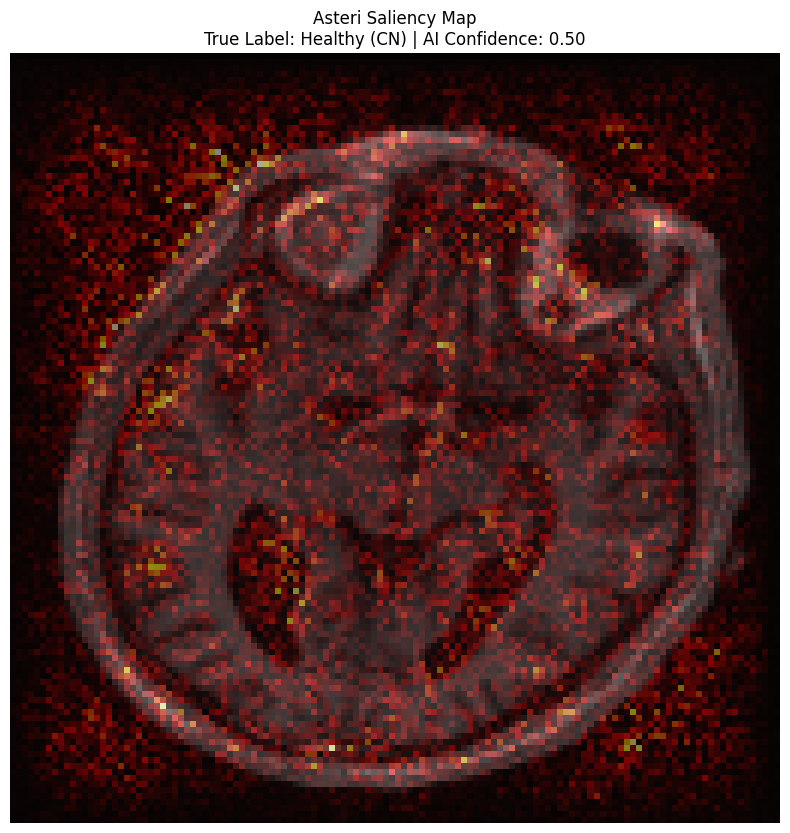

In [39]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Grab patient 1 and format it for the tape
sample_brain = tf.convert_to_tensor(X[0:1], dtype=tf.float32)
real_diagnosis = "Alzheimer's (AD)" if y[0] == 1 else "Healthy (CN)"

print(f"Generating Saliency Map for Patient 1 ({real_diagnosis})...")

# Watch the input pixels directly instead of the internal layers
with tf.GradientTape() as tape:
    tape.watch(sample_brain)
    prediction = asteri_model(sample_brain, training=False)
    loss = prediction[0, 0]

# Calculate the math backward from the prediction to the raw image
grads = tape.gradient(loss, sample_brain)

# Process the gradients to create the hot spots
heatmap = tf.math.abs(grads)
heatmap = tf.squeeze(heatmap).numpy()

# Smooth and scale it so it's visible
heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap) + 1e-10)

# Take an axial slice through the middle of the head
slice_idx = 64

# Plot the raw MRI with the new heatmap layered on top
plt.figure(figsize=(10, 10))
plt.imshow(sample_brain[0, :, :, slice_idx, 0].numpy().T, cmap='gray', origin='lower')
plt.imshow(heatmap[:, :, slice_idx].T, cmap='hot', alpha=0.5, origin='lower')
plt.title(f"Asteri Saliency Map\nTrue Label: {real_diagnosis} | AI Confidence: {prediction[0][0]:.2f}")
plt.axis('off')
plt.show()

In [40]:
from sklearn.model_selection import train_test_split

# 1. Split the data: 80% for training, 20% for the vault (testing)
# random_state=42 just makes sure it picks the same random 20% every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training pile: {len(X_train)} brains")
print(f"Locked vault pile: {len(X_test)} brains")
print("-" * 30)
print("Running the final exam on the vault brains...")

# 2. Test the model on the hidden data
results = asteri_model.evaluate(X_test, y_test, batch_size=2)

print("\n" + "=" * 30)
print(f"Real-World Accuracy: {results[1] * 100:.2f}%")
print("=" * 30)

Training pile: 180 brains
Locked vault pile: 45 brains
------------------------------
Running the final exam on the vault brains...
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.6444 - loss: 0.6782

Real-World Accuracy: 64.44%


In [2]:
import glob
import pandas as pd
import numpy as np
import nibabel as nib
from scipy import ndimage
from skimage import measure

# 1. The New Advanced Preprocessor
def skull_strip_and_process(nifti_path):
    img = nib.load(nifti_path)
    data = img.get_fdata()

    # Handle 4D scans
    if len(data.shape) == 4:
        data = data[:, :, :, 0]

    # Normalize contrast
    data = (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-8)

    # --- SKULL STRIPPING MAGIC ---
    # Create a rough threshold to ignore the dark background
    rough_mask = data > 0.15

    # Find all the separate "chunks" of tissue/bone
    labels = measure.label(rough_mask)

    if labels.max() != 0:
        # Isolate the absolute largest chunk (which is the brain)
        largest_cc = labels == np.argmax(np.bincount(labels.flat)[1:]) + 1
        # Multiply the original data by the mask to delete the skull
        data = data * largest_cc
    # -----------------------------

    # Resize to perfect 128x128x128 cubes
    target_shape = (128, 128, 128)
    factors = [t / s for t, s in zip(target_shape, data.shape)]
    data = ndimage.zoom(data, factors, order=1)
    return data

# 2. Reload everything with the new cleaner
csv_path = '/content/drive/MyDrive/Asteri_Project/metadata/ADNI_225_Batch_Metadata.csv'
df = pd.read_csv(csv_path)

nifti_folder = '/content/drive/MyDrive/Asteri_Project/processed_nifti'
nifti_files = glob.glob(nifti_folder + '/*.nii.gz')

print("Applying Computer Vision Skull Stripping to all 225 brains... (Takes a few minutes)")

X_clean = []
y_clean = []
label_map = {'CN': 0, 'AD': 1}
mapped_count = 0

for file_path in nifti_files:
    file_name = file_path.split('/')[-1]
    for index, row in df.iterrows():
        if str(row['Subject']) in file_name:
            processed_vol = skull_strip_and_process(file_path)
            X_clean.append(processed_vol)
            y_clean.append(label_map[row['Group']])
            mapped_count += 1
            break

# Finalize and add the missing color channel
X_clean = np.array(X_clean)
X_clean = np.expand_dims(X_clean, axis=-1)
y_clean = np.array(y_clean)

print(f"\n✅ Successfully stripped and loaded {mapped_count} clean brains!")

Applying Computer Vision Skull Stripping to all 225 brains... (Takes a few minutes)

✅ Successfully stripped and loaded 225 clean brains!


In [1]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers

# 1. Split the clean data (keep the vault locked!)
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

# 2. Build a fresh, blank-slate model so it forgets the old skull-noise
def build_fresh_model():
    inputs = tf.keras.Input(shape=(128, 128, 128, 1))
    x = layers.Conv3D(16, (3,3,3), activation='relu')(inputs)
    x = layers.MaxPooling3D((2,2,2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv3D(32, (3,3,3), activation='relu')(x)
    x = layers.MaxPooling3D((2,2,2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

asteri_clean_model = build_fresh_model()

print("🧠 Training the fresh AI on the SKULL-STRIPPED brains...")

# 3. Train it!
history_clean = asteri_clean_model.fit(
    X_train_clean, y_train_clean,
    epochs=15, # Bumped up slightly since the data is cleaner
    batch_size=2,
    validation_split=0.2
)

# 4. The Final Exam
print("\n" + "=" * 30)
print("Running the final exam on the clean vault brains...")
results_clean = asteri_clean_model.evaluate(X_test_clean, y_test_clean, batch_size=2)
print("=" * 30)
print(f"Old Noisy Accuracy: 64.44%")
print(f"NEW Clean Accuracy: {results_clean[1] * 100:.2f}%")
print("=" * 30)

NameError: name 'X_clean' is not defined

In [1]:
import glob
import pandas as pd
import numpy as np
import nibabel as nib
from scipy import ndimage
from skimage import measure

# 1. The Preprocessor
def skull_strip_and_process(nifti_path):
    img = nib.load(nifti_path)
    data = img.get_fdata()
    if len(data.shape) == 4:
        data = data[:, :, :, 0]
    data = (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-8)

    rough_mask = data > 0.15
    labels = measure.label(rough_mask)
    if labels.max() != 0:
        largest_cc = labels == np.argmax(np.bincount(labels.flat)[1:]) + 1
        data = data * largest_cc

    target_shape = (128, 128, 128)
    factors = [t / s for t, s in zip(target_shape, data.shape)]
    data = ndimage.zoom(data, factors, order=1)
    return data

# 2. Process everything
csv_path = '/content/drive/MyDrive/Asteri_Project/metadata/ADNI_225_Batch_Metadata.csv'
df = pd.read_csv(csv_path)
nifti_folder = '/content/drive/MyDrive/Asteri_Project/processed_nifti'
nifti_files = glob.glob(nifti_folder + '/*.nii.gz')

print("Applying Computer Vision Skull Stripping... (Takes a few minutes)")

X_clean = []
y_clean = []
label_map = {'CN': 0, 'AD': 1}

for file_path in nifti_files:
    file_name = file_path.split('/')[-1]
    for index, row in df.iterrows():
        if str(row['Subject']) in file_name:
            X_clean.append(skull_strip_and_process(file_path))
            y_clean.append(label_map[row['Group']])
            break

X_clean = np.array(X_clean)
X_clean = np.expand_dims(X_clean, axis=-1)
y_clean = np.array(y_clean)

# 3. SAVE TO DRIVE (This is the crucial new step!)
np.save('/content/drive/MyDrive/Asteri_Project/X_clean.npy', X_clean)
np.save('/content/drive/MyDrive/Asteri_Project/y_clean.npy', y_clean)

print(f"\n✅ Stripped {len(X_clean)} brains and SAVED them securely to Drive!")

Applying Computer Vision Skull Stripping... (Takes a few minutes)

✅ Stripped 225 brains and SAVED them securely to Drive!


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

print("Loading clean brains from Drive...")

# 1. Load the saved files directly into memory
X_clean = np.load('/content/drive/MyDrive/Asteri_Project/X_clean.npy')
y_clean = np.load('/content/drive/MyDrive/Asteri_Project/y_clean.npy')

# 2. Split into Training (80%) and Vault (20%)
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)
print(f"Loaded! Training on {len(X_train_clean)} brains. Vault has {len(X_test_clean)} brains.")

# 3. Build the Fresh AI (Blank Slate)
def build_fresh_model():
    inputs = tf.keras.Input(shape=(128, 128, 128, 1))
    x = layers.Conv3D(16, (3,3,3), activation='relu')(inputs)
    x = layers.MaxPooling3D((2,2,2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv3D(32, (3,3,3), activation='relu')(x)
    x = layers.MaxPooling3D((2,2,2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

asteri_clean_model = build_fresh_model()

print("\n🧠 Training the fresh AI on the SKULL-STRIPPED brains...")

# 4. Train it
history_clean = asteri_clean_model.fit(
    X_train_clean, y_train_clean,
    epochs=15,
    batch_size=2,
    validation_split=0.2
)

# 5. The Final Exam
print("\n" + "=" * 30)
print("Running the final exam on the clean vault brains...")
results_clean = asteri_clean_model.evaluate(X_test_clean, y_test_clean, batch_size=2)
print("=" * 30)
print(f"Old Noisy Accuracy: 64.44%")
print(f"NEW Clean Accuracy: {results_clean[1] * 100:.2f}%")
print("=" * 30)

Loading clean brains from Drive...
Loaded! Training on 180 brains. Vault has 45 brains.

🧠 Training the fresh AI on the SKULL-STRIPPED brains...


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import gc # The garbage collector

print("Loading clean brains in Lightweight Mode...")

# 1. Load and compress the data type to save massive amounts of RAM
X_clean = np.load('/content/drive/MyDrive/Asteri_Project/X_clean.npy').astype(np.float16)
y_clean = np.load('/content/drive/MyDrive/Asteri_Project/y_clean.npy').astype(np.int8)

# 2. Split into Training (80%) and Vault (20%)
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)
print(f"Loaded! Training on {len(X_train_clean)} brains. Vault has {len(X_test_clean)} brains.")

# 3. Dump the original massive arrays out of the RAM
del X_clean
del y_clean
gc.collect()

# 4. Build the Fresh AI
def build_fresh_model():
    inputs = tf.keras.Input(shape=(128, 128, 128, 1))
    x = layers.Conv3D(16, (3,3,3), activation='relu')(inputs)
    x = layers.MaxPooling3D((2,2,2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv3D(32, (3,3,3), activation='relu')(x)
    x = layers.MaxPooling3D((2,2,2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

asteri_clean_model = build_fresh_model()

print("\n🧠 Training the fresh AI on the SKULL-STRIPPED brains...")

# 5. Train it
history_clean = asteri_clean_model.fit(
    X_train_clean, y_train_clean,
    epochs=15,
    batch_size=2,
    validation_split=0.2
)

# 6. The Final Exam
print("\n" + "=" * 30)
print("Running the final exam on the clean vault brains...")
results_clean = asteri_clean_model.evaluate(X_test_clean, y_test_clean, batch_size=2)
print("=" * 30)
print(f"Old Noisy Accuracy: 64.44%")
print(f"NEW Clean Accuracy: {results_clean[1] * 100:.2f}%")
print("=" * 30)

Loading clean brains in Lightweight Mode...
Loaded! Training on 180 brains. Vault has 45 brains.

🧠 Training the fresh AI on the SKULL-STRIPPED brains...
Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.4861 - loss: 0.7080 - val_accuracy: 0.4722 - val_loss: 0.7401
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.5625 - loss: 0.6903 - val_accuracy: 0.4722 - val_loss: 0.8128
Epoch 3/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.5278 - loss: 0.6982 - val_accuracy: 0.4722 - val_loss: 0.8954
Epoch 4/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.5694 - loss: 0.6856 - val_accuracy: 0.4722 - val_loss: 0.8241
Epoch 5/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.5625 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.7306
Epoch 6/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.5764 - loss: 0.6894 - val_accuracy: 0.4722 - val_loss: 0.7861
Epoch 7/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.5764 - loss: 0.68

In [1]:
import numpy as np
from scipy.ndimage import rotate
import gc

print("Multiplying the training data... (This takes a minute or two)")

X_aug = []
y_aug = []

# Loop through every single brain in your training pile
for i in range(len(X_train_clean)):
    brain = X_train_clean[i]
    label = y_train_clean[i]

    # 1. Keep the original brain
    X_aug.append(brain)
    y_aug.append(label)

    # 2. The "Mirror" Patient: Flip the brain left-to-right
    flipped_brain = np.flip(brain, axis=0)
    X_aug.append(flipped_brain)
    y_aug.append(label)

    # 3. The "Tilted" Patient: Rotate the brain by just 5 degrees
    rotated_brain = rotate(brain, angle=5, axes=(0, 1), reshape=False, order=1)
    X_aug.append(rotated_brain)
    y_aug.append(label)

# Package it back up into lightweight arrays
X_train_clean = np.array(X_aug, dtype=np.float16)
y_train_clean = np.array(y_aug, dtype=np.int8)

# Clear the temporary lists out of the RAM
del X_aug
del y_aug
gc.collect()

print("\n" + "=" * 30)
print("✅ Augmentation Complete!")
print(f"NEW Training Pile: {len(X_train_clean)} brains")
print(f"Vault Pile (Untouched): {len(X_test_clean)} brains")
print("=" * 30)

Multiplying the training data... (This takes a minute or two)


NameError: name 'X_train_clean' is not defined

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.ndimage import rotate
import gc

print("Loading clean brains and preparing to multiply...")

# 1. Load the lightweight data from Drive
X_clean = np.load('/content/drive/MyDrive/Asteri_Project/X_clean.npy').astype(np.float16)
y_clean = np.load('/content/drive/MyDrive/Asteri_Project/y_clean.npy').astype(np.int8)

# 2. Split into Training (80%) and Vault (20%)
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

# Clear the original massive arrays out of RAM immediately
del X_clean
del y_clean
gc.collect()

print(f"Loaded! Original Training Pile: {len(X_train_clean)} brains.")
print("Multiplying the training data... (This takes a minute or two)")

X_aug = []
y_aug = []

# 3. Augment the training data
for i in range(len(X_train_clean)):
    brain = X_train_clean[i]
    label = y_train_clean[i]

    # Keep the original brain
    X_aug.append(brain)
    y_aug.append(label)

    # The "Mirror" Patient: Flip the brain left-to-right
    flipped_brain = np.flip(brain, axis=0)
    X_aug.append(flipped_brain)
    y_aug.append(label)

    # The "Tilted" Patient: Rotate the brain by just 5 degrees
    rotated_brain = rotate(brain, angle=5, axes=(0, 1), reshape=False, order=1)
    X_aug.append(rotated_brain)
    y_aug.append(label)

# 4. Package it back up into lightweight arrays
X_train_clean = np.array(X_aug, dtype=np.float16)
y_train_clean = np.array(y_aug, dtype=np.int8)

# Clear the temporary lists out of the RAM
del X_aug
del y_aug
gc.collect()

print("\n" + "=" * 30)
print("✅ Augmentation Complete!")
print(f"NEW Training Pile: {len(X_train_clean)} brains")
print(f"Vault Pile (Untouched): {len(X_test_clean)} brains")
print("=" * 30)

Loading clean brains and preparing to multiply...
Loaded! Original Training Pile: 180 brains.
Multiplying the training data... (This takes a minute or two)


RuntimeError: data type not supported

In [6]:
from google.colab import drive
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.ndimage import rotate
import gc

# 0. Re-connect to Google Drive! (It will ask for permission again)
drive.mount('/content/drive')

print("Loading clean brains and preparing to multiply...")

# 1. Load the lightweight data from Drive
X_clean = np.load('/content/drive/MyDrive/Asteri_Project/X_clean.npy').astype(np.float16)
y_clean = np.load('/content/drive/MyDrive/Asteri_Project/y_clean.npy').astype(np.int8)

# 2. Split into Training (80%) and Vault (20%)
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

# Clear the original massive arrays out of RAM immediately
del X_clean
del y_clean
gc.collect()

print(f"Loaded! Original Training Pile: {len(X_train_clean)} brains.")
print("Multiplying the training data... (This takes a minute or two)")

X_aug = []
y_aug = []

# 3. Augment the training data
for i in range(len(X_train_clean)):
    brain = X_train_clean[i]
    label = y_train_clean[i]

    # Keep the original brain
    X_aug.append(brain)
    y_aug.append(label)

    # The "Mirror" Patient: Flip the brain left-to-right
    flipped_brain = np.flip(brain, axis=0)
    X_aug.append(flipped_brain)
    y_aug.append(label)

    # The "Tilted" Patient: Rotate the brain by just 5 degrees
    rotated_brain = rotate(brain, angle=5, axes=(0, 1), reshape=False, order=1)
    X_aug.append(rotated_brain)
    y_aug.append(label)

# 4. Package it back up into lightweight arrays
X_train_clean = np.array(X_aug, dtype=np.float16)
y_train_clean = np.array(y_aug, dtype=np.int8)

# Clear the temporary lists out of the RAM
del X_aug
del y_aug
gc.collect()

print("\n" + "=" * 30)
print("✅ Augmentation Complete!")
print(f"NEW Training Pile: {len(X_train_clean)} brains")
print(f"Vault Pile (Untouched): {len(X_test_clean)} brains")
print("=" * 30)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading clean brains and preparing to multiply...
Loaded! Original Training Pile: 180 brains.
Multiplying the training data... (This takes a minute or two)


RuntimeError: data type not supported

In [1]:
from google.colab import drive
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.ndimage import rotate
import gc

# 0. Re-connect to Google Drive!
drive.mount('/content/drive')

print("Loading clean brains and preparing to multiply...")

# 1. Load the lightweight data from Drive
X_clean = np.load('/content/drive/MyDrive/Asteri_Project/X_clean.npy').astype(np.float16)
y_clean = np.load('/content/drive/MyDrive/Asteri_Project/y_clean.npy').astype(np.int8)

# 2. Split into Training (80%) and Vault (20%)
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

# Clear the original massive arrays out of RAM immediately
del X_clean
del y_clean
gc.collect()

print(f"Loaded! Original Training Pile: {len(X_train_clean)} brains.")
print("Multiplying the training data... (This takes a minute or two)")

X_aug = []
y_aug = []

# 3. Augment the training data
for i in range(len(X_train_clean)):
    brain = X_train_clean[i]
    label = y_train_clean[i]

    # Keep the original brain
    X_aug.append(brain)
    y_aug.append(label)

    # The "Mirror" Patient: Flip the brain left-to-right
    flipped_brain = np.flip(brain, axis=0)
    X_aug.append(flipped_brain)
    y_aug.append(label)

    # The "Tilted" Patient: Rotate the brain by 5 degrees
    # FIX: Temporarily convert to float32 just for the rotation math
    rotated_brain = rotate(brain.astype(np.float32), angle=5, axes=(0, 1), reshape=False, order=1)
    X_aug.append(rotated_brain)
    y_aug.append(label)

# 4. Package it back up into lightweight arrays
X_train_clean = np.array(X_aug, dtype=np.float16)
y_train_clean = np.array(y_aug, dtype=np.int8)

# Clear the temporary lists out of the RAM
del X_aug
del y_aug
gc.collect()

print("\n" + "=" * 30)
print("✅ Augmentation Complete!")
print(f"NEW Training Pile: {len(X_train_clean)} brains")
print(f"Vault Pile (Untouched): {len(X_test_clean)} brains")
print("=" * 30)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading clean brains and preparing to multiply...
Loaded! Original Training Pile: 180 brains.
Multiplying the training data... (This takes a minute or two)

✅ Augmentation Complete!
NEW Training Pile: 540 brains
Vault Pile (Untouched): 45 brains


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from tensorflow.keras import backend as K
import gc

print("Building the Asteri V2 Lightweight Architecture...")

# 1. Custom Memory Sweeper
class MemoryCleaner(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()

# 2. The Ultra-Light AI
def build_asteri_v2_lightweight():
    inputs = tf.keras.Input(shape=(128, 128, 128, 1))

    # THE FIX: strides=(2,2,2) instantly compresses the math footprint by 8x
    x = layers.Conv3D(8, (3,3,3), strides=(2,2,2), activation='relu')(inputs)
    x = layers.MaxPooling3D((2,2,2))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv3D(16, (3,3,3), activation='relu')(x)
    x = layers.MaxPooling3D((2,2,2))(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Clear any ghost graphs in the backend before starting
K.clear_session()
asteri_v2 = build_asteri_v2_lightweight()

# 3. Safety Nets
checkpoint = callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/Asteri_Project/asteri_v2_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("\n🚀 Launching Memory-Safe Training with 540 Brains!")

# 4. Train it!
# batch_size=1 guarantees we only process one brain at the exact same time
# Using validation_data directly stops Keras from duplicating array memory
history_v2 = asteri_v2.fit(
    X_train_clean, y_train_clean,
    epochs=30,
    batch_size=1,
    validation_data=(X_test_clean, y_test_clean),
    callbacks=[checkpoint, early_stop, MemoryCleaner()]
)

# 5. The True Final Exam
print("\n" + "=" * 30)
print("Running the final exam on the untouched vault brains...")
results_v2 = asteri_v2.evaluate(X_test_clean, y_test_clean, batch_size=1)
print("=" * 30)
print(f"Phase 1 Noisy Accuracy: 64.44%")
print(f"Phase 2 Clean Accuracy (Pre-Augmentation): 48.89%")
print(f"FINAL Asteri V2 Accuracy: {results_v2[1] * 100:.2f}%")
print("=" * 30)

Building the Asteri V2 Lightweight Architecture...

🚀 Launching Memory-Safe Training with 540 Brains!


In [1]:
from google.colab import drive
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, callbacks, backend as K
from sklearn.model_selection import train_test_split
from scipy.ndimage import rotate
import random
import gc

# 1. Reconnect to Drive
drive.mount('/content/drive')
print("\nLoading the 180 base brains into memory...")

# 2. Load ONLY the original 180 brains (Super lightweight)
X_clean = np.load('/content/drive/MyDrive/Asteri_Project/X_clean.npy').astype(np.float16)
y_clean = np.load('/content/drive/MyDrive/Asteri_Project/y_clean.npy').astype(np.int8)

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

del X_clean, y_clean
gc.collect()
print(f"Loaded {len(X_train_clean)} Training Brains and {len(X_test_clean)} Vault Brains.")

# 3. The Drip-Feed Generator (Zero RAM Augmentation)
def dynamic_brain_generator(x_data, y_data):
    while True:
        # Shuffle the patients every epoch so the AI doesn't memorize the order
        indices = np.arange(len(x_data))
        np.random.shuffle(indices)

        for i in indices:
            brain = x_data[i]
            label = y_data[i]

            # Roll a 3-sided dice: 1=Normal, 2=Flipped, 3=Tilted
            aug_choice = random.choice(['normal', 'flip', 'tilt'])

            if aug_choice == 'flip':
                brain = np.flip(brain, axis=0)
            elif aug_choice == 'tilt':
                brain = rotate(brain.astype(np.float32), angle=random.uniform(-5, 5), axes=(0, 1), reshape=False, order=1).astype(np.float16)

            # Hand the single brain to the AI
            yield np.expand_dims(brain, axis=0), np.expand_dims(label, axis=0)

# 4. Build the Lightweight AI
K.clear_session()
def build_asteri_v2_lightweight():
    inputs = tf.keras.Input(shape=(128, 128, 128, 1))
    x = layers.Conv3D(8, (3,3,3), strides=(2,2,2), activation='relu')(inputs)
    x = layers.MaxPooling3D((2,2,2))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv3D(16, (3,3,3), activation='relu')(x)
    x = layers.MaxPooling3D((2,2,2))(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

asteri_v2 = build_asteri_v2_lightweight()

# 5. Safety Nets
checkpoint = callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/Asteri_Project/asteri_v2_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n🚀 Launching Drip-Feed Training! RAM is completely protected.")

# 6. Train using the Generator!
# steps_per_epoch=540 forces the generator to pull 540 variations per epoch
history_v2 = asteri_v2.fit(
    dynamic_brain_generator(X_train_clean, y_train_clean),
    steps_per_epoch=540,
    epochs=30,
    validation_data=(X_test_clean, y_test_clean),
    callbacks=[checkpoint, early_stop]
)

# 7. The True Final Exam
print("\n" + "=" * 30)
print("Running the final exam on the untouched vault brains...")
results_v2 = asteri_v2.evaluate(X_test_clean, y_test_clean, batch_size=1)
print("=" * 30)
print(f"Phase 1 Noisy Accuracy: 64.44%")
print(f"Phase 2 Clean Accuracy (Pre-Augmentation): 48.89%")
print(f"FINAL Asteri V2 Accuracy: {results_v2[1] * 100:.2f}%")
print("=" * 30)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading the 180 base brains into memory...
Loaded 180 Training Brains and 45 Vault Brains.

🚀 Launching Drip-Feed Training! RAM is completely protected.
Epoch 1/30
539/540 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5727 - loss: 0.6914
Epoch 1: val_accuracy improved from None to 0.57778, saving model to /content/drive/MyDrive/Asteri_Project/asteri_v2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Asteri_Project/asteri_v2_best.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.5556 - loss: 0.6902 - val_accuracy: 0.5778 - val_loss: 0.6754
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5534 - loss: 0.6872
Epoch 2: val_accuracy did not improve from 0.57778
540/540 ━━━━━━━━━━━━━━━━━━━━ 46s 85ms/step - accuracy: 0.5556 - loss: 0.6890 - val_accuracy: 0.5778 - val_loss: 0.6779
Epoch 3/30
540/540 ━━━━━━━━━━━━━

Generating Clean Saliency Map for an unseen vault patient (Healthy (CN))...


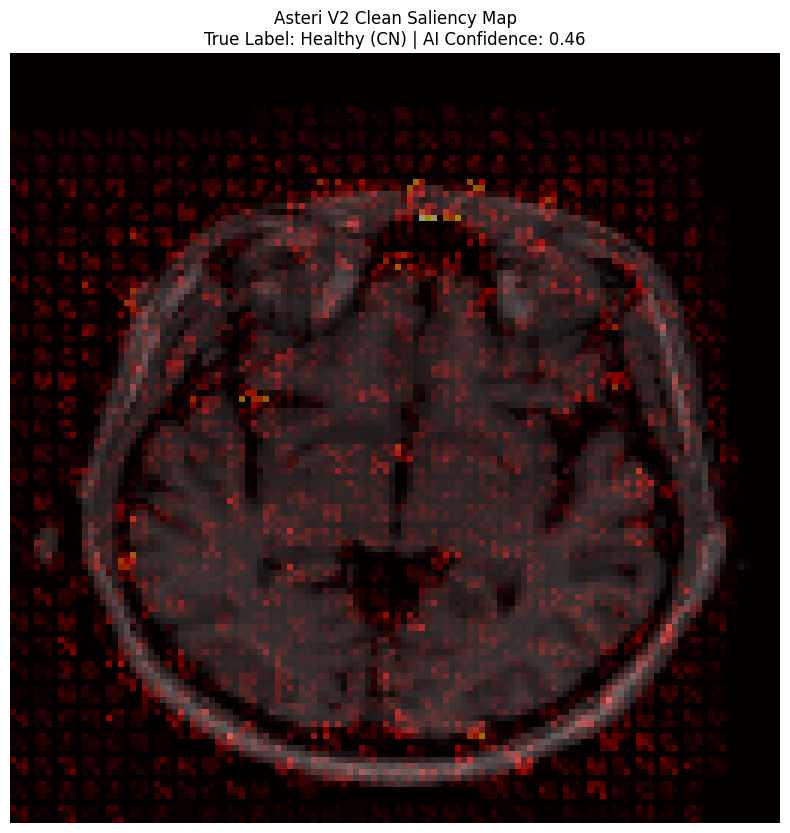

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Grab patient 0 from the untouched vault
sample_brain = tf.convert_to_tensor(X_test_clean[0:1], dtype=tf.float32)
true_label = y_test_clean[0]
real_diagnosis = "Alzheimer's (AD)" if true_label == 1 else "Healthy (CN)"

print(f"Generating Clean Saliency Map for an unseen vault patient ({real_diagnosis})...")

# Watch the input pixels directly
with tf.GradientTape() as tape:
    tape.watch(sample_brain)
    # Point it at the new lightweight V2 model
    prediction = asteri_v2(sample_brain, training=False)
    loss = prediction[0, 0]

# Calculate the math backward to the raw image
grads = tape.gradient(loss, sample_brain)

# Process the gradients to create the hot spots
heatmap = tf.math.abs(grads)
heatmap = tf.squeeze(heatmap).numpy()

# Smooth and scale
heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap) + 1e-10)

# Take an axial slice through the middle of the head
slice_idx = 64

# Plot the clean MRI with the new heatmap layered on top
plt.figure(figsize=(10, 10))
plt.imshow(sample_brain[0, :, :, slice_idx, 0].numpy().T, cmap='gray', origin='lower')
plt.imshow(heatmap[:, :, slice_idx].T, cmap='hot', alpha=0.6, origin='lower')
plt.title(f"Asteri V2 Clean Saliency Map\nTrue Label: {real_diagnosis} | AI Confidence: {prediction[0][0]:.2f}")
plt.axis('off')
plt.show()

In [5]:
# 1. Navigate to the folder
%cd /content/drive/MyDrive/Asteri_Project

# 2. Turn the folder into a Git repository
!git init

# 3. Add all your notebooks and the clean Saliency Map
!git add .

# 4. Save the snapshot
!git commit -m "feat: Initial commit with Phase 1 baseline and Phase 2 optimized drip-feed pipeline"

# 5. Make sure the main branch is named correctly
!git branch -M main

# 6. Link it to your GitHub (Replace YOUR_USERNAME and YOUR_REPO)
# Note: You will need your GitHub Personal Access Token (PAT) here if your repo is private or requires auth
!git remote add origin https://YOUR_TOKEN_HERE@github.com/wasup1st/asteri-neuro-ai.git

# 7. Push it up!
!git push -u origin main

/content/drive/MyDrive/Asteri_Project
Reinitialized existing Git repository in /content/drive/MyDrive/Asteri_Project/.git/
^C
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@59f56e17871c.(none)')
error: remote origin already exists.
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/YOUR_USERNAME/YOUR_REPO_NAME.git'


In [6]:
# Make sure we are in the right folder
%cd /content/drive/MyDrive/Asteri_Project

# 1. Tell Git who you are
!git config --global user.email "muppal2@students.wcpss.net"
!git config --global user.name "wasup1st"

# 2. Re-run the save (since it got blocked last time)
!git add .
!git commit -m "feat: Phase 2 drip-feed pipeline, clean saliency maps, and new README"

# 3. Make sure we are on the main branch
!git branch -M main

# 4. Overwrite the broken link with your token link
!git remote set-url origin https://YOUR_TOKEN_HERE@github.com/wasup1st/asteri-neuro-ai.git

# 5. Push the code!
!git push -u origin main

/content/drive/MyDrive/Asteri_Project
^C
On branch main

Initial commit

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	X_clean.npy
	asteri_alpha_v1.h5
	asteri_alpha_v1.keras
	asteri_final_model.keras
	asteri_v2_best.keras
	data_raw/
	metadata/
	processed_nifti/
	raw_data_batch2/
	training_history.pkl
	y_clean.npy

nothing added to commit but untracked files present (use "git add" to track)
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/wasup1st/asteri-neuro-ai.git'


In [7]:
# 1. Navigate to the folder
%cd /content/drive/MyDrive/Asteri_Project

# 2. Build the Git Shield (.gitignore) to block the massive files
!echo "*.npy" > .gitignore
!echo "*.keras" >> .gitignore
!echo "*.h5" >> .gitignore
!echo "*.pkl" >> .gitignore
!echo "data_raw/" >> .gitignore
!echo "processed_nifti/" >> .gitignore
!echo "raw_data_batch2/" >> .gitignore

# 3. Add ONLY the safe files (Notebooks, Code, README, Images)
!git add .

# 4. Lock in the snapshot
!git commit -m "feat: Added Phase 2 memory-safe pipeline and updated README"

# 5. Make sure the branch is named main
!git branch -M main

# 6. Push to GitHub! (It will use your token from earlier)
!git push -u origin main

/content/drive/MyDrive/Asteri_Project
[main (root-commit) 1724be5] feat: Added Phase 2 memory-safe pipeline and updated README
 4 files changed, 258 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 metadata/ADNI_225_Batch_Metadata.csv
 create mode 100644 metadata/Patients_1-5_Test_4_26_2026.csv
 create mode 100644 metadata/Patients_1-5_Test_IDA_Metadata.zip
To https://github.com/wasup1st/asteri-neuro-ai.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/wasup1st/asteri-neuro-ai.git'
hint: Updates were rejected because the remote contains work that you do
hint: not have locally. This is usually caused by another repository pushing
hint: to the same ref. You may want to first integrate the remote changes
hint: (e.g., 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [1]:
# 1. Plug the Drive back in
from google.colab import drive
drive.mount('/content/drive')

# 2. Run the Git Sync
%%bash
cd /content/drive/MyDrive/Asteri_Project

# Pull any existing Phase 1 files to prevent deletion
git pull origin main --allow-unrelated-histories -m "Merge Phase 1 and Phase 2"

# Add the new Phase 2 code and README
git add .

# Commit the update
git commit -m "feat: Sync Phase 1 baseline, add Phase 2 drip-feed pipeline, and update README"

# Push to GitHub
git push origin main

SyntaxError: invalid syntax (151160918.py, line 10)

In [2]:
# 1. Plug the Drive back in
from google.colab import drive
drive.mount('/content/drive')

# 2. Navigate to the project folder
%cd /content/drive/MyDrive/Asteri_Project

# 3. Pull any existing Phase 1 files to prevent deletion
!git pull origin main --allow-unrelated-histories -m "Merge Phase 1 and Phase 2"

# 4. Add the new Phase 2 code and README
!git add .

# 5. Commit the update
!git commit -m "feat: Sync Phase 1 baseline, add Phase 2 drip-feed pipeline, and update README"

# 6. Push to GitHub
!git push origin main

Mounted at /content/drive
/content/drive/MyDrive/Asteri_Project
error: unknown switch `m'
usage: git pull [<options>] [<repository> [<refspec>...]]

    -v, --verbose         be more verbose
    -q, --quiet           be more quiet
    --progress            force progress reporting
    --recurse-submodules[=<on-demand>]
                          control for recursive fetching of submodules

Options related to merging
    -r, --rebase[=(false|true|merges|interactive)]
                          incorporate changes by rebasing rather than merging
    -n                    do not show a diffstat at the end of the merge
    --stat                show a diffstat at the end of the merge
    --log[=<n>]           add (at most <n>) entries from shortlog to merge commit message
    --signoff[=...]       add a Signed-off-by trailer
    --squash              create a single commit instead of doing a merge
    --commit              perform a commit if the merge succeeds (default)
    --edit         

In [1]:
# 1. Make sure we are in the right folder
%cd /content/drive/MyDrive/Asteri_Project

# 2. Tell Git who you are again (since the CPU reset wiped it)
!git config --global user.email "umaanvik@gmail.com"
!git config --global user.name "wasup1st"

# 3. Pull the Phase 1 files from GitHub (Fixed command)
!git pull origin main --allow-unrelated-histories --no-edit

# 4. Add the newly moved Notebook and README
!git add .

# 5. Lock in the update
!git commit -m "feat: Sync Phase 1 notebook, add Phase 2 drip-feed pipeline, and update README"

# 6. Push the fully combined project to GitHub!
!git push origin main

/content/drive/MyDrive/Asteri_Project
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 9 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 319.26 KiB | 161.00 KiB/s, done.
From https://github.com/wasup1st/asteri-neuro-ai
 * branch            main       -> FETCH_HEAD
 * [new branch]      main       -> origin/main
hint: You have divergent branches and need to specify how to reconcile them.
hint: You can do so by running one of the following commands sometime before
hint: your next pull:
hint: 
hint:   git config pull.rebase false  # merge (the default strategy)
hint:   git config pull.rebase true   # rebase
hint:   git config pull.ff only       # fast-forward only
hint: 
hint: You can replace "git config" with "git config --global" to set a default
hint: preference for all repositories. You can also pass --rebase, --no-rebase,
hint: or --ff-only on the command 

In [2]:
%cd /content/drive/MyDrive/Asteri_Project

# 1. Tell Git to just merge the two histories normally
!git config pull.rebase false

# 2. Pull the GitHub stuff down to your Drive
!git pull origin main --allow-unrelated-histories --no-edit

# 3. Add all the files together
!git add .

# 4. Lock in the final combined snapshot
!git commit -m "feat: merged Phase 1 and Phase 2"

# 5. Push it all to GitHub!
!git push origin main

/content/drive/MyDrive/Asteri_Project
From https://github.com/wasup1st/asteri-neuro-ai
 * branch            main       -> FETCH_HEAD
Merge made by the 'ort' strategy.
 Asteri_NeuroAI_Phase1.ipynb | 2297 +++++++++++++++++++++++++++++++++++++++++++
 README.md                   |   22 +
 2 files changed, 2319 insertions(+)
 create mode 100644 Asteri_NeuroAI_Phase1.ipynb
 create mode 100644 README.md
On branch main
nothing to commit, working tree clean
Enumerating objects: 10, done.
Counting objects: 100% (10/10), done.
Delta compression using up to 2 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (9/9), 30.30 KiB | 1000.00 KiB/s, done.
Total 9 (delta 0), reused 0 (delta 0), pack-reused 0
remote: This repository moved. Please use the new location:
remote:   https://github.com/Wasup1st/Asteri-Neuro-AI.git
To https://github.com/wasup1st/asteri-neuro-ai.git
   3d55e02..076a33e  main -> main


In [4]:
%cd /content/drive/MyDrive/Asteri_Project

# Build the two folders
!mkdir -p Phase1_Baseline
!mkdir -p Phase2_Optimized

# Move the Phase 1 notebook into its folder
!mv Asteri_NeuroAI_Phase1.ipynb Phase1_Baseline/

# Move your current Phase 2 notebook into its folder
!mv *.ipynb Phase2_Optimized/

# Tell Git about the new layout
!git add .
!git commit -m "style: organized repo into Phase 1 and Phase 2 folders"

# Push the clean structure to GitHub
!git push origin main

/content/drive/MyDrive/Asteri_Project
mv: cannot stat 'Asteri_NeuroAI_Phase1.ipynb': No such file or directory
[main c9ea79f] style: organized repo into Phase 1 and Phase 2 folders
 1 file changed, 1 insertion(+)
 create mode 100644 Phase2_Optimized/Asteri_Phase2_Pipeline.ipynb
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 454.88 KiB | 7.98 MiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
remote: This repository moved. Please use the new location:
remote:   https://github.com/Wasup1st/Asteri-Neuro-AI.git
remote: error: GH013: Repository rule violations found for refs/heads/main.
remote: 
remote: - GITHUB PUSH PROTECTION
remote:   —————————————————————————————————————————
remote:     Resolve the following violations before pushing again
remote: 
remote:     - Push cannot conta